# Exploratory Data Analysis

This notebook explores the cleaned Sales table produced by "src/preprocess.py".
It imports the pipeline modules from "src/" rather than re-implementing anything,
reads paths from "config.yaml", and saves every figure to "reports/figures/" for
the report.

In [1]:
import sys
from pathlib import Path

# Make the repo root importable no matter where the notebook is launched from.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import CFG, resolve

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

FIGS = resolve(CFG["paths"]["figures"])
FIGS.mkdir(parents=True, exist_ok=True)
DATE = CFG["data"]["date_col"]
TARGET = CFG["data"]["target_col"]


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")
    print("saved", FIGS / f"{name}.png")

In [2]:
df = pd.read_parquet(resolve(CFG["paths"]["cleaned"]))
print(df.shape)
df.head(3)

(1311171, 23)


,trans_group_en,procedure_name_en,instance_date,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_name_en,building_name_en,project_name_en,...,nearest_mall_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,bedrooms
0,Sales,Delayed Sell,2022-11-09,Land,Unknown,Commercial,Existing Properties,Jabal Ali First,NaN,Jebel Ali Village Townhouses- Phase 1,...,Unknown,Unknown,0,382.36,"3,088,800.00","8,078.25",1.00,1.00,0.00,<NA>
1,Sales,Sell - Pre registration,2025-06-02,Unit,Flat,Residential,Off-Plan Properties,Al Barsha South Fourth,Azizi Ruby,Azizi Ruby,...,Marina Mall,1 B/R,1,64.38,"1,089,000.00","16,915.19",1.00,2.00,0.00,1
2,Sales,Sell,2015-03-26,Unit,Office,Commercial,Existing Properties,Al Thanyah Fifth,MAZAYA BUSINESS AVENUE AA1,BUSINESS AVENUE AA1,...,Marina Mall,Office,1,157.14,"1,192,472.00","7,588.60",1.00,1.00,0.00,<NA>


## 1. Date integrity 

instance_date
1975       1
1990       1
1992       1
1993       1
1997      49
1998    1309
1999     888
2000     901
2001    1421
2002    1891
2003    2041
2004    2789
2005    2530
2006    2622
2007    9025
Name: count, dtype: int64
saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\transactions_per_year.png
rows before 2002: 4,572 (0.35%)
rows before 2008: 25,470 (1.94%)


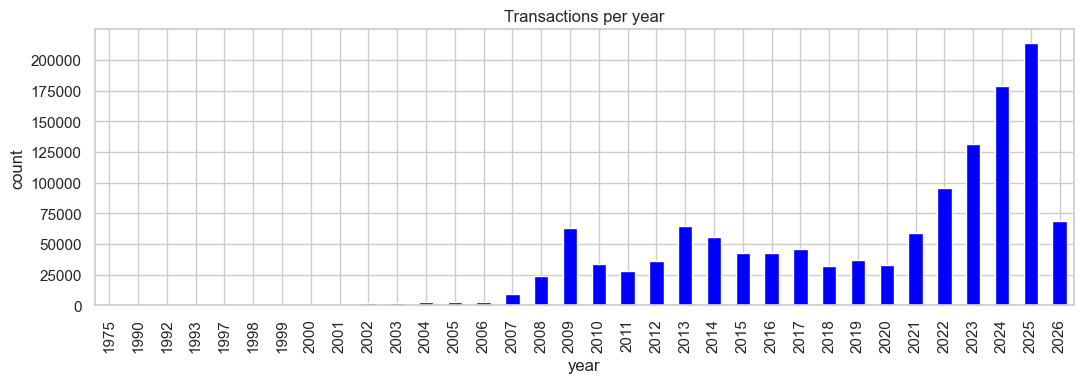

In [6]:
year = df[DATE].dt.year
counts = year.value_counts().sort_index()
print(counts.head(15))

fig, ax = plt.subplots(figsize=(11, 4))
counts.plot(kind="bar", ax=ax, color="blue")
ax.set(title="Transactions per year", xlabel="year", ylabel="count")
ax.tick_params(axis="x", labelrotation=90)
save(fig, "transactions_per_year")

for cut in (2002, 2008):
    n = int((year < cut).sum())
    print(f"rows before {cut}: {n:,} ({n / len(df) * 100:.2f}%)")

NOTE: Need to cut off pre-2008 years

## 2. Target distribution and the log transform

Property prices are heavily right-skewed, which is why the models train on log1p(actual_worth).
The two panels show why: raw AED is unusable, the log scale is roughly bell-shaped.

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\target_distribution.png


count     1,311,171.00
mean      2,499,105.19
std       4,826,751.43
min          50,000.00
25%         762,828.00
50%       1,371,000.00
75%       2,507,000.00
max     100,000,000.00
Name: actual_worth, dtype: float64

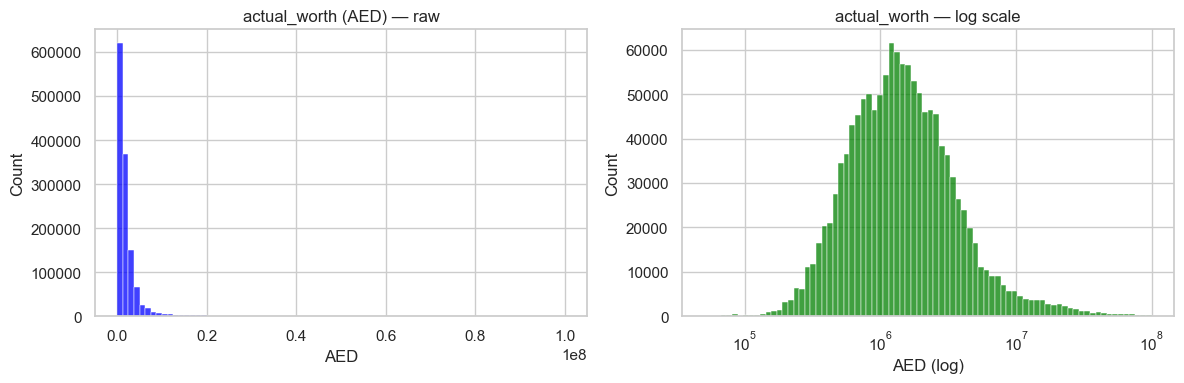

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=80, ax=axes[0], color="blue")
axes[0].set(title="actual_worth (AED) — raw", xlabel="AED")
sns.histplot(df[TARGET], bins=80, log_scale=True, ax=axes[1], color="green")
axes[1].set(title="actual_worth — log scale", xlabel="AED (log)")
save(fig, "target_distribution")
df[TARGET].describe()

NOTE: log transform is justified

## 3. Price vs size

procedure_area on a log-log scale the
relationship should be close to linear.

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\price_vs_area.png


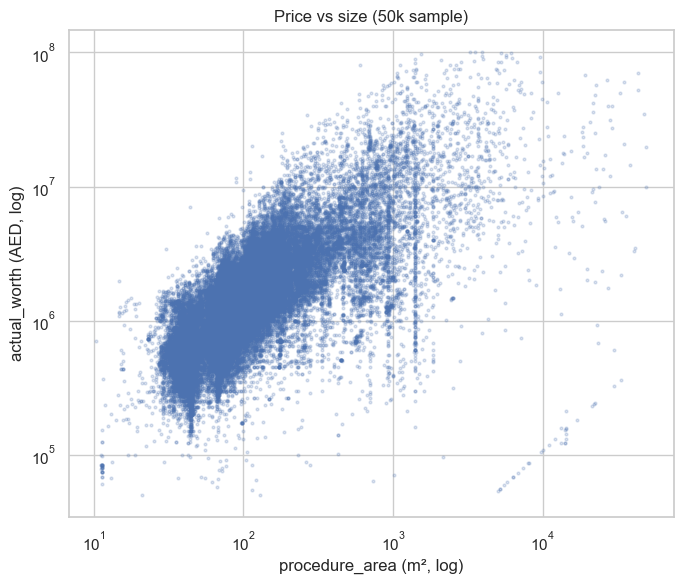

In [7]:
s = df.sample(min(50_000, len(df)), random_state=CFG["seed"])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(s["procedure_area"], s[TARGET], s=4, alpha=0.2)
ax.set(xscale="log", yscale="log",
       xlabel="procedure_area (m², log)", ylabel="actual_worth (AED, log)",
       title="Price vs size (50k sample)")
save(fig, "price_vs_area")

## 4. Price by categorical drivers

Property type, registration type (off-plan vs existing), and usage should each
shift the price distribution.

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\price_by_category.png


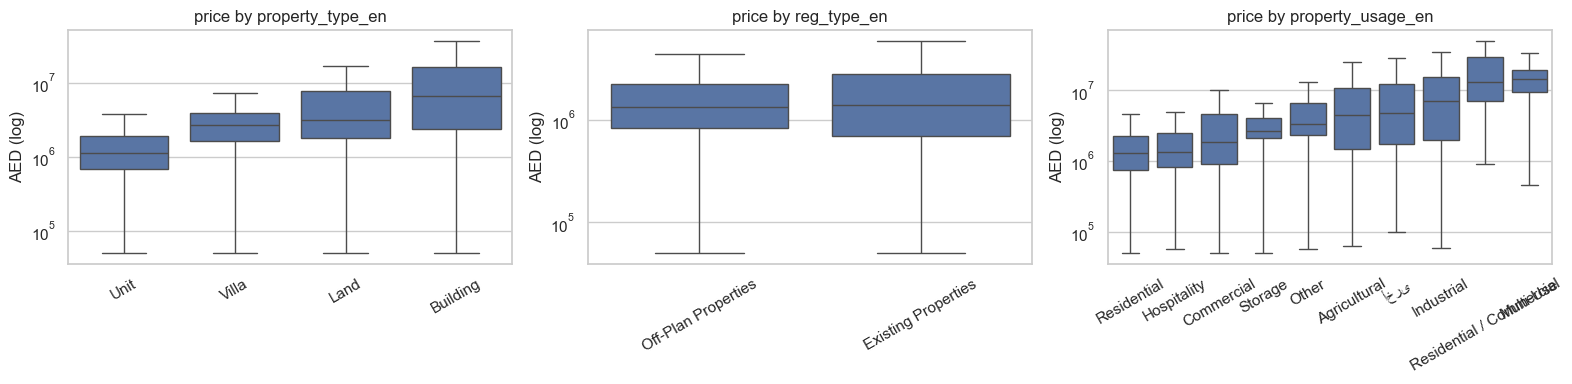

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["property_type_en", "reg_type_en", "property_usage_en"]):
    order = df.groupby(col)[TARGET].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, showfliers=False)
    ax.set_yscale("log")
    ax.tick_params(axis="x", labelrotation=30)
    ax.set(title=f"price by {col}", xlabel="", ylabel="AED (log)")
save(fig, "price_by_category")

In [ ]:
df['property_usage_en'].value_counts()

property_usage_en
Residential                 1115685
Commercial                   123306
Hospitality                   36337
Other                         24412
أخرى                           4372
Multi-Use                      3493
Industrial                     2738
Agricultural                    520
Storage                         290
Residential / Commercial         18
Name: count, dtype: int64[pyarrow]

NOTE: arabic value missed and it has high frequency so its not cleaned by the one hot encoder (min_frequency = 10), needs to be handled

## 5. Bedrooms

The numeric bedrooms we parsed out of rooms_en should rise monotonically
with price for residential units.

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\price_by_bedrooms.png


bedrooms
0      562,000.00
1    1,042,874.00
2    1,817,828.00
3    2,550,000.00
4    3,200,000.00
5    4,422,594.00
6   17,910,000.00
7   36,007,000.00
8   39,387,064.00
9    1,434,495.00
Name: actual_worth, dtype: float64

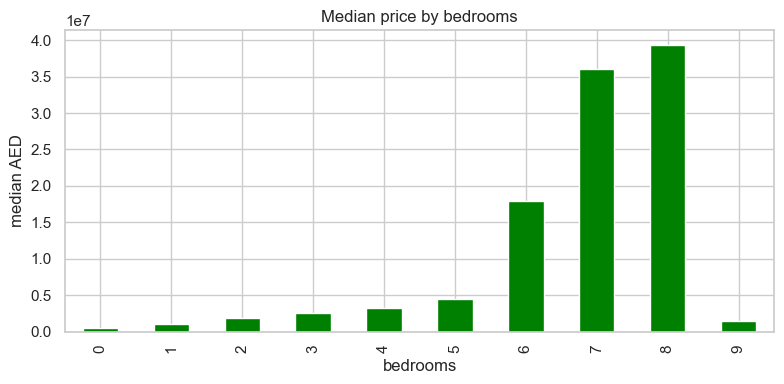

In [10]:
br = df.dropna(subset=["bedrooms"]).copy()
br["bedrooms"] = br["bedrooms"].astype(int)
med = br.groupby("bedrooms")[TARGET].median()
fig, ax = plt.subplots(figsize=(8, 4))
med.plot(kind="bar", ax=ax, color="green")
ax.set(title="Median price by bedrooms", xlabel="bedrooms", ylabel="median AED")
save(fig, "price_by_bedrooms")
med

NOTE: 9 bedrooms is a small artifact

## 6. Location: community count and price spread

area_name_en has too many distinct communities to one-hot, which is why it's
target-encoded. The table shows the highest-volume communities and how their
median prices differ.

cardinality per categorical:
area_name_en            237
nearest_metro_en         57
property_sub_type_en     20
procedure_name_en        18
rooms_en                 17
nearest_landmark_en      15
property_usage_en        10
nearest_mall_en           6
property_type_en          4
reg_type_en               2
dtype: int64

top-15 communities by volume:
                                    count       median
area_name_en                                          
Marsa Dubai                        104072 1,696,895.00
Business Bay                        95027 1,372,000.00
Al Barsha South Fourth              90653   823,741.00
Al Thanyah Fifth                    72156 1,080,000.00
Burj Khalifa                        54857 2,320,000.00
Al Warsan First                     51709   355,000.00
Wadi Al Safa 5                      47513 1,182,974.00
Jabal Ali First                     47472   972,000.00
Al Hebiah Fourth                    38172   798,237.50
Al Merkadh                          35246 

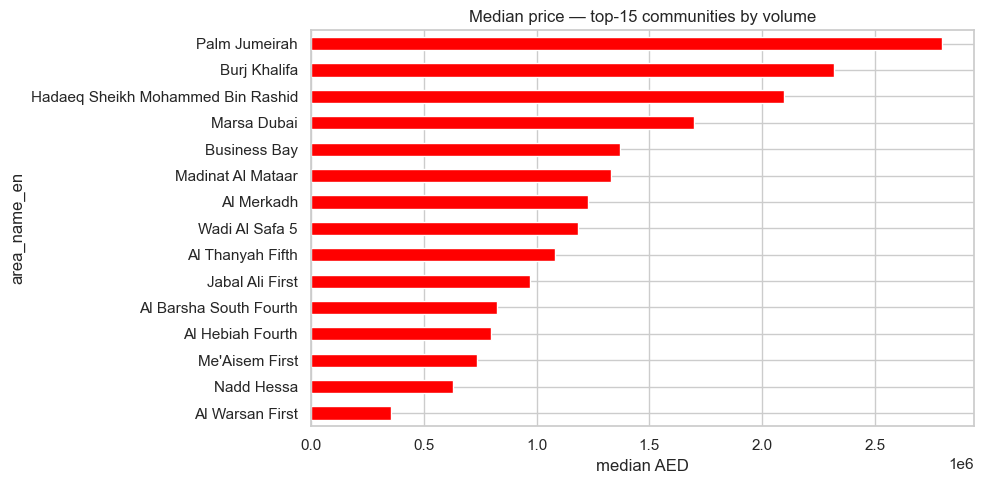

In [11]:
cat_cols = CFG["data"]["categorical_features"]
print("cardinality per categorical:")
print(df[cat_cols].nunique().sort_values(ascending=False))

top = (df.groupby("area_name_en")[TARGET]
         .agg(["count", "median"]).sort_values("count", ascending=False).head(15))
print("\ntop-15 communities by volume:")
print(top)

fig, ax = plt.subplots(figsize=(10, 5))
top["median"].sort_values().plot(kind="barh", ax=ax, color="red")
ax.set(title="Median price — top-15 communities by volume", xlabel="median AED")
save(fig, "top_communities")

NOTE: area_name_en target encoding is justified

## 7. Proximity to metro

A tagged nearest-metro station should carry a price premium versus rows where
none is tagged, confirming if the proximity features are worth keeping.

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\price_by_metro_presence.png


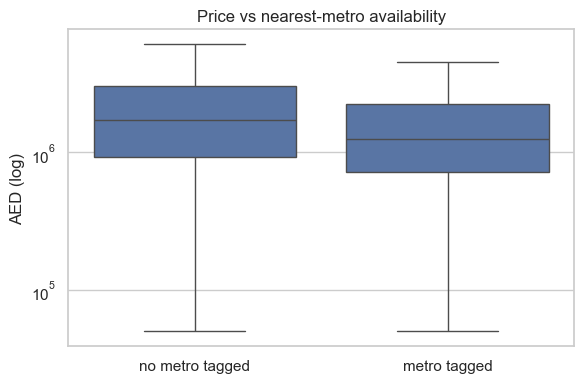

In [12]:
metro_flag = np.where(df["nearest_metro_en"].eq("Unknown"),
                      "no metro tagged", "metro tagged")
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=metro_flag, y=df[TARGET], showfliers=False, ax=ax)
ax.set_yscale("log")
ax.set(title="Price vs nearest-metro availability", xlabel="", ylabel="AED (log)")
save(fig, "price_by_metro_presence")

NOTE: no metro premium? There might be some data integrity issues (unlikely because the data is from DLD). The fact that its the opposite is weird, but I think we can keep it for the opposite relationship

## 8. "Unknown" share per categorical

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\unknown_share.png


nearest_mall_en        32.90
nearest_metro_en       32.27
nearest_landmark_en    22.11
rooms_en               16.64
property_sub_type_en   15.09
property_type_en        0.00
procedure_name_en       0.00
reg_type_en             0.00
property_usage_en       0.00
area_name_en            0.00
dtype: float64

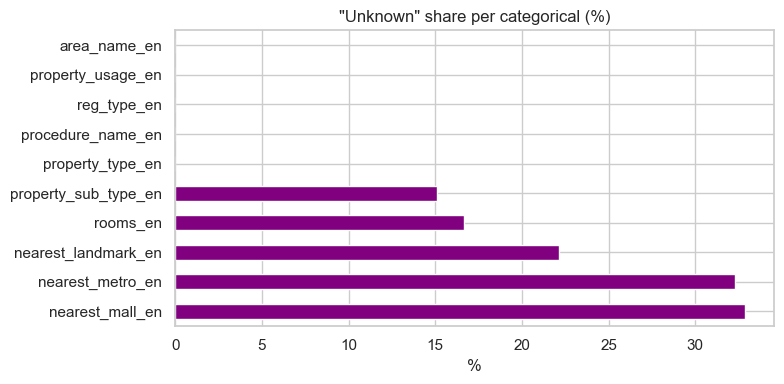

In [13]:
unknown_share = {c: (df[c] == "Unknown").mean() * 100 for c in cat_cols}
us = pd.Series(unknown_share).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
us.plot(kind="barh", ax=ax, color="purple")
ax.set(title='"Unknown" share per categorical (%)', xlabel="%")
save(fig, "unknown_share")
us

## 9. Market trend over time

Median price and volume by year. This is the trend the model has to track, and
it's why the train/test split is temporal rather than random.

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\price_trend.png


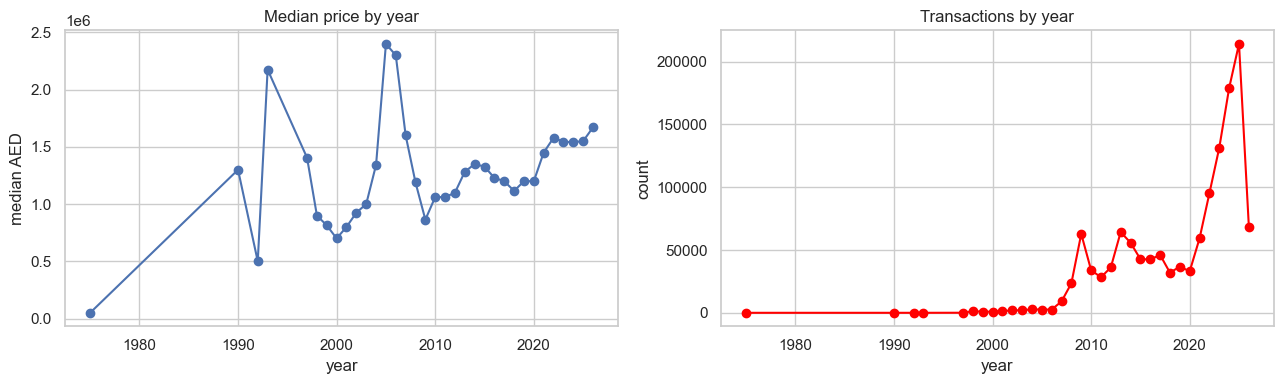

In [14]:
yearly_med = df.groupby(df[DATE].dt.year)[TARGET].median()
yearly_cnt = df.groupby(df[DATE].dt.year).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
yearly_med.plot(ax=axes[0], marker="o")
axes[0].set(title="Median price by year", xlabel="year", ylabel="median AED")
yearly_cnt.plot(ax=axes[1], marker="o", color="red")
axes[1].set(title="Transactions by year", xlabel="year", ylabel="count")
save(fig, "price_trend")

NOTE: confirms again that pre-2008 data is mostly noise